# Reliability Analysis Workflow

This notebook performs reliability analysis on fetal brain MRI segmentations.

## Workflow:
1. **Cell 1**: Import required libraries
2. **Cell 2**: Configuration (set paths, subject ID, session ID, PDF output path)
3. **Cell 3**: Helper functions (image processing, metrics calculation)
4. **Cell 4**: Process all splits and compute per-split metrics (optional visualization)
5. **Cell 5**: Split comparison visualization (stores figure for PDF)
6. **Cell 6**: Cross-split reliability analysis function definition
7. **Cell 7**: **Combined reliability analysis** - Runs all analyses and creates 2-page PDF:
   - **Page 1**: Split comparison visualization (SP Model vs 5-Label Model)
   - **Page 2**: Three cross-split reliability matrices stacked vertically:
     - Cortical Plate (SP Model)
     - Subplate (SP Model)
     - Cortical Plate (5-Label Model)

## Output:
- **PDF file**: `cross_split_reliability_report.pdf` (appends for each subject)
- **CSV file**: `cross_split_metrics.csv` (cumulative metrics across all subjects)

## To run for a new subject:
1. Update `subject_id` and `session_id` in Cell 2
2. Run cells 1-7 sequentially
3. Results will be appended to the PDF

In [1]:
#Imports
import nibabel as nib
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from matplotlib.backends.backend_pdf import PdfPages
import os
from scipy.spatial.distance import directed_hausdorff
from sklearn.metrics import jaccard_score
import pandas as pd

In [2]:
# 1. Configuration
base_path = "/home/yair/Projects/Tests"
subject_id = "FCB145"
session_id = "2019.03.20-032Y-MR_EI_Fetal_Neuro-29197"
splits = ["S1", "S2", "S3", "S4"]

# Only measure CP between 5-labels and SP model in per-split comparision (Only shared labels between the two models)
labels_to_measure = [1, 42]

# Custom label names
label_names = {
    1: "Left Cortical Plate",
    42: "Right Cortical Plate",
}

# PDF output path for cross-split reliability plots
pdf_output_path = f"reports/{subject_id}_{session_id}_reliability_report.pdf"

In [3]:
# Parameters
subject_id = "FCB187"
session_id = "2022.06.10-MR-EI_Fetal_Neuro-26465115"
pdf_output_path = "reports/FCB187_2022.06.10-MR-EI_Fetal_Neuro-26465115_reliability_report.pdf"


In [4]:
# 2. Helper functions
def get_middle_slice(data, axis):
    return data.shape[axis] // 2

def normalize_intensity(img_data, lower_percentile=1, upper_percentile=99):
    lower, upper = np.percentile(img_data, [lower_percentile, upper_percentile])
    img_normalized = np.clip(img_data, lower, upper)
    return (img_normalized - lower) / (upper - lower)

def dice_coefficient(seg1, seg2):
    intersection = np.sum(seg1 * seg2)
    return 2.0 * intersection / (np.sum(seg1) + np.sum(seg2)) if (np.sum(seg1) + np.sum(seg2)) > 0 else 0

def hausdorff_distance(seg1, seg2):
    coords1, coords2 = np.argwhere(seg1), np.argwhere(seg2)
    if len(coords1) == 0 or len(coords2) == 0:
        return np.inf
    return max(directed_hausdorff(coords1, coords2)[0], directed_hausdorff(coords2, coords1)[0])

def relative_voxel_difference(seg1, seg2):
    count1 = np.sum(seg1)
    count2 = np.sum(seg2)
    
    if count1 == 0 and count2 == 0:
        return 0.0
    
    # Use a mean count of boxels instead of voxels of a single count of voxels of a segmentation
    mean_count = (count1 + count2) / 2.0
    if mean_count == 0:
        return 0.0
    
    return abs(count1 - count2) / mean_count * 100.0

def load_freesurfer_lut(path):
    lut_colors = {}
    with open(path, "r") as f:
        for line in f:
            line = line.strip()
            if line and not line.startswith("#"):
                parts = line.split()
                if len(parts) >= 5:
                    try:
                        label_idx = int(parts[0])
                        lut_colors[label_idx] = (int(parts[2]) / 255.0, int(parts[3]) / 255.0, 
                                                  int(parts[4]) / 255.0, 1.0)
                    except (ValueError, IndexError):
                        continue
    lut_colors[0] = (0, 0, 0, 0)
    return lut_colors


Processing FCB187 - S1


Overall (labels [1, 42]): Dice=0.454, Jaccard=0.294, VoxelDiff=10.59%
Left Cortical Plate: Dice=0.472, Jaccard=0.308, VoxelDiff=12.15%
Right Cortical Plate: Dice=0.435, Jaccard=0.278, VoxelDiff=9.04%


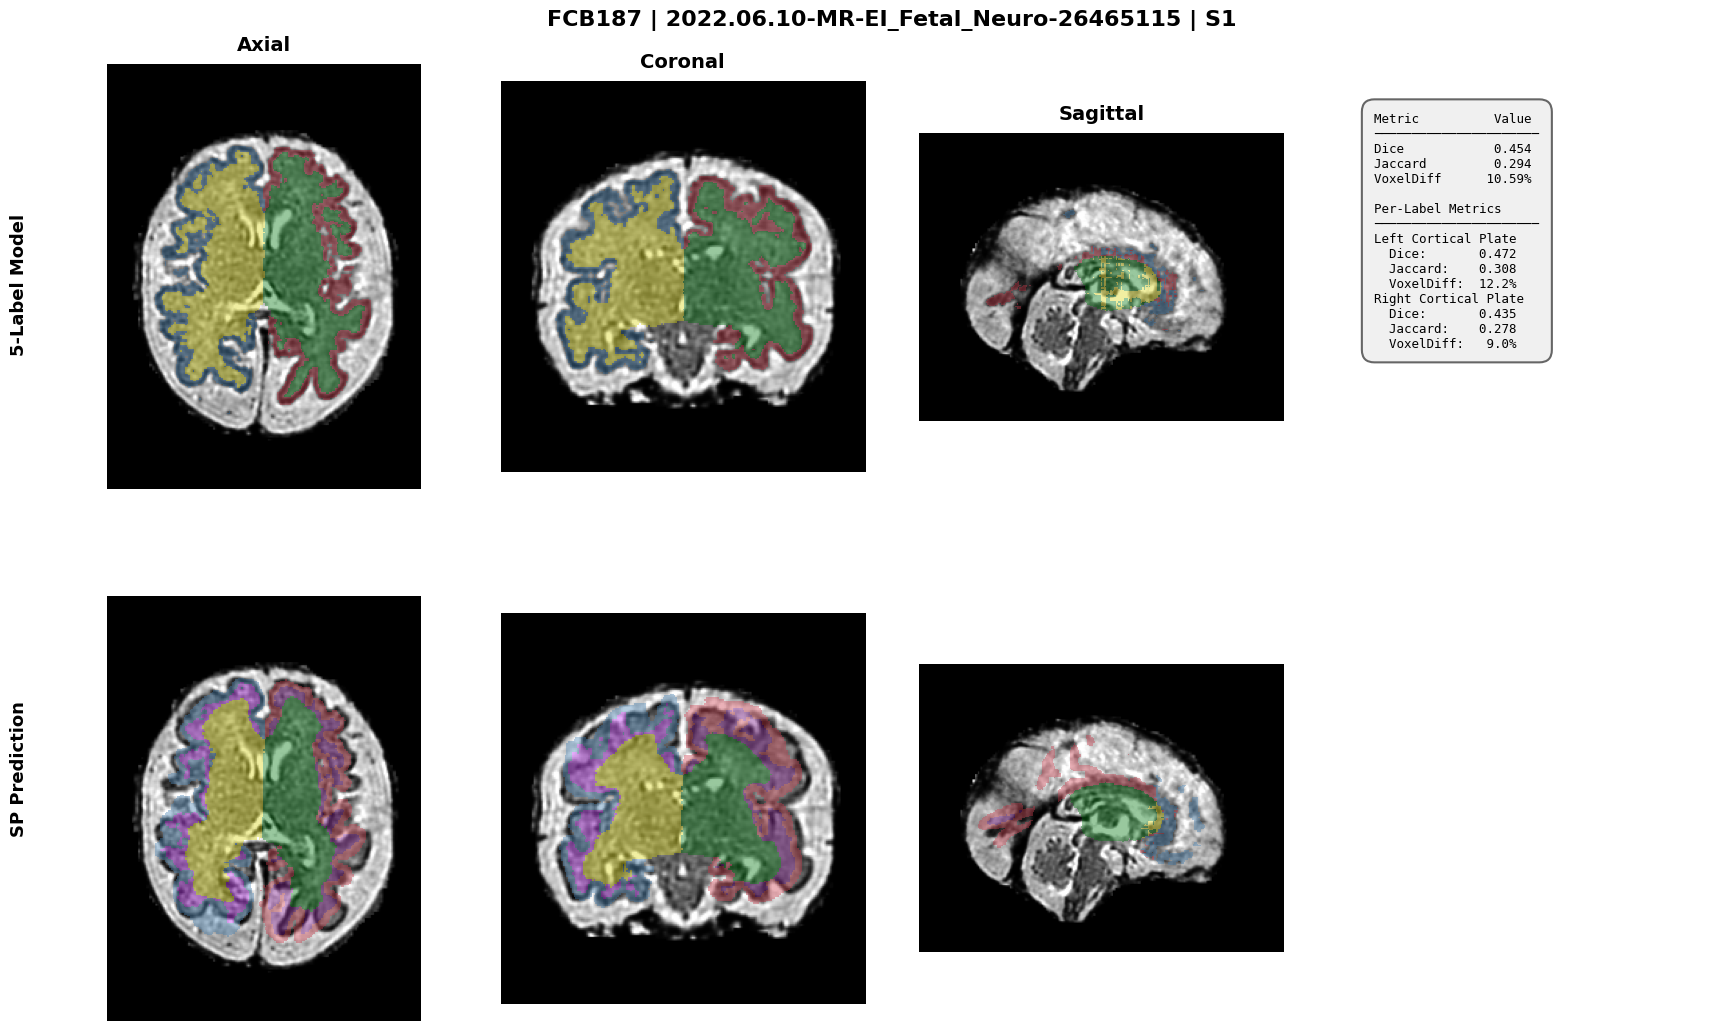


Processing FCB187 - S2


Overall (labels [1, 42]): Dice=0.457, Jaccard=0.296, VoxelDiff=11.62%
Left Cortical Plate: Dice=0.473, Jaccard=0.309, VoxelDiff=12.60%
Right Cortical Plate: Dice=0.441, Jaccard=0.283, VoxelDiff=10.65%


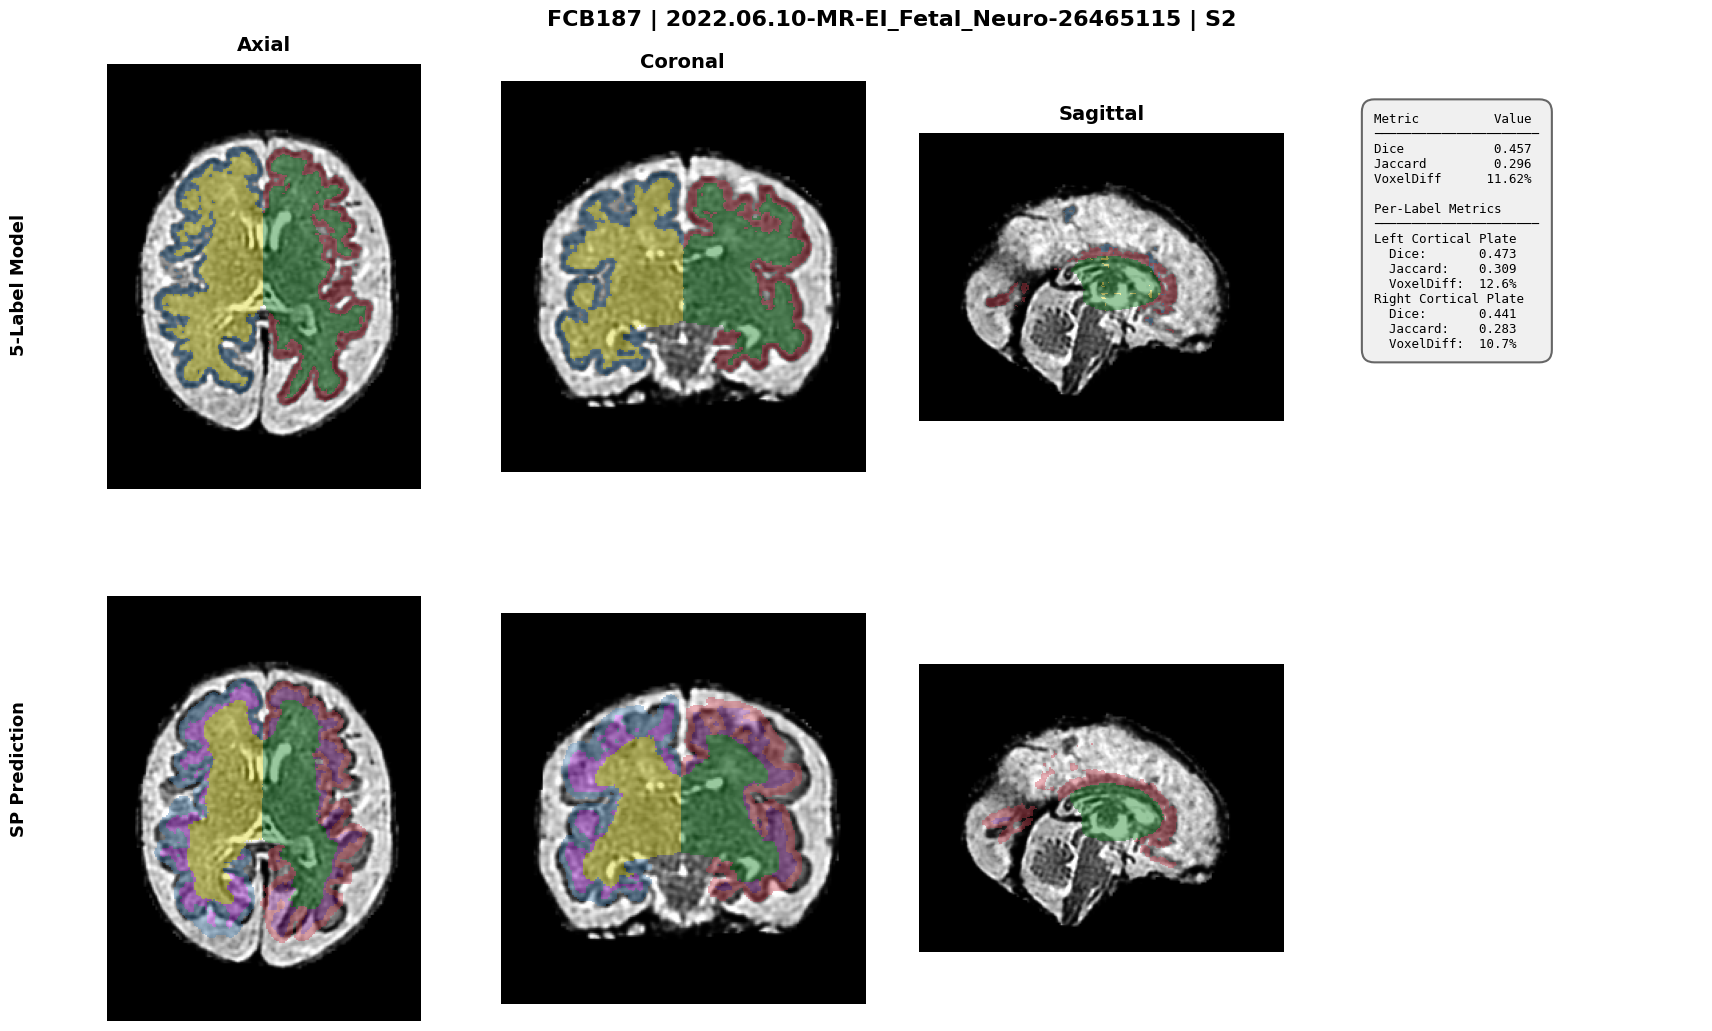


Processing FCB187 - S3


Overall (labels [1, 42]): Dice=0.434, Jaccard=0.277, VoxelDiff=13.18%
Left Cortical Plate: Dice=0.460, Jaccard=0.299, VoxelDiff=14.20%
Right Cortical Plate: Dice=0.408, Jaccard=0.256, VoxelDiff=12.16%


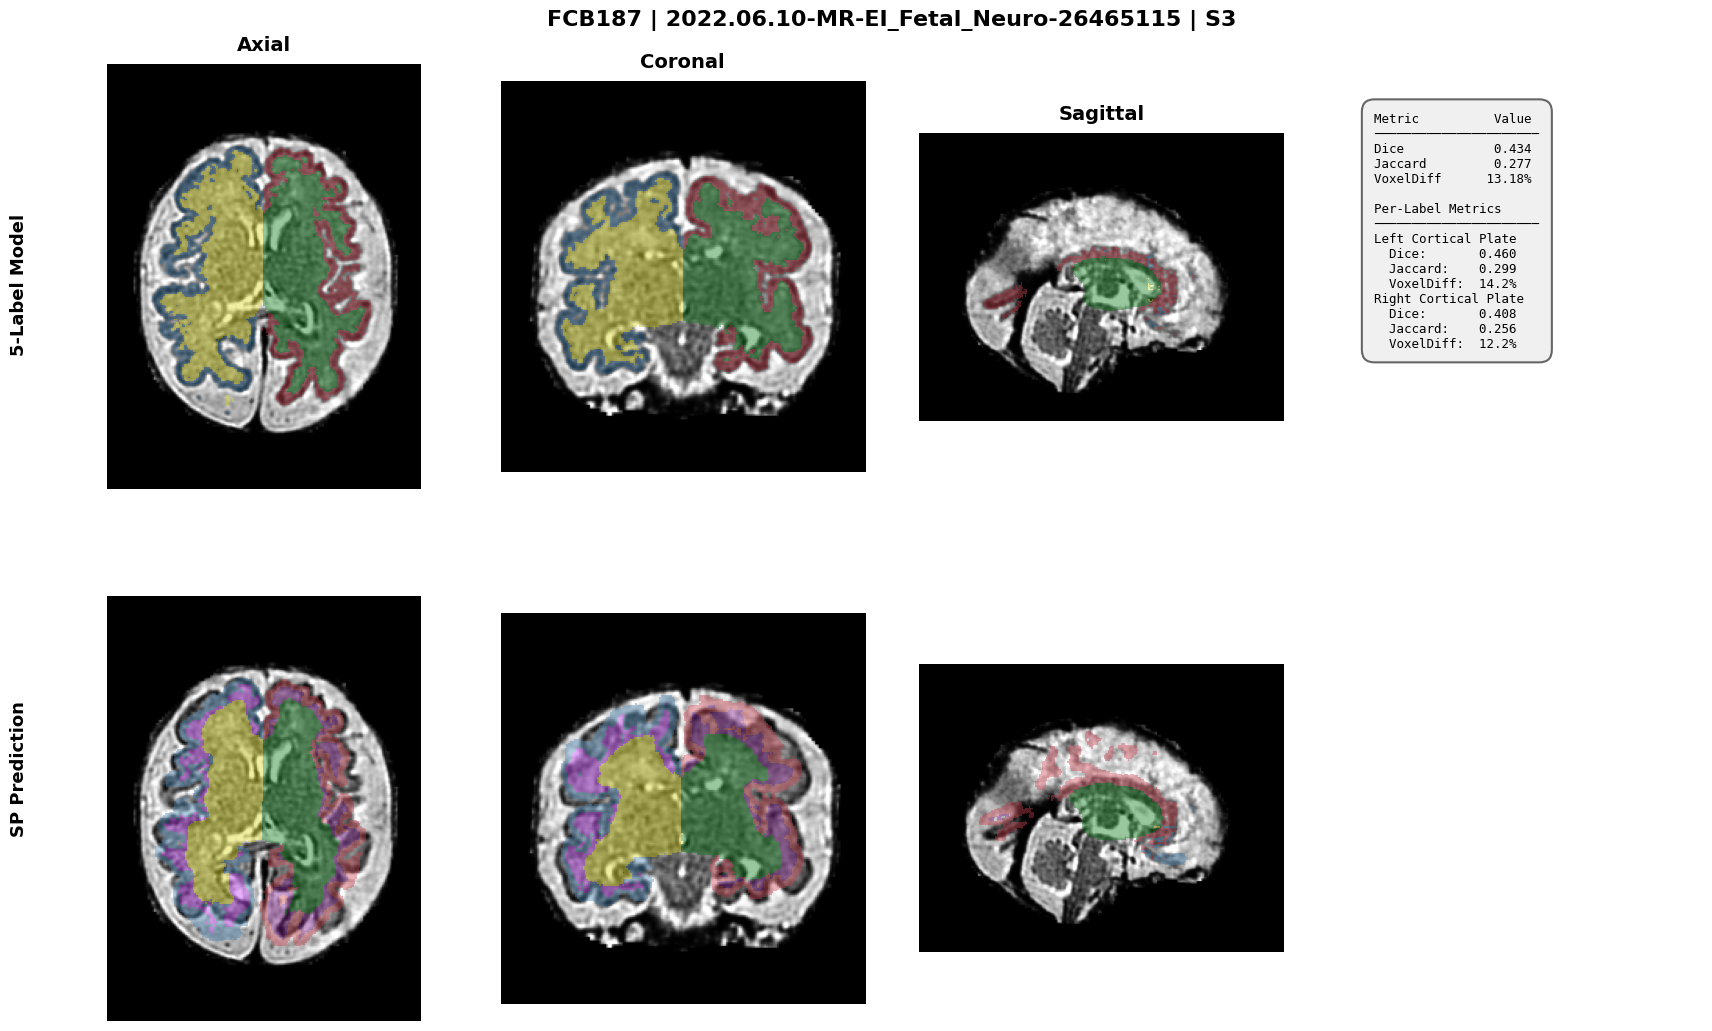


Processing FCB187 - S4


Overall (labels [1, 42]): Dice=0.459, Jaccard=0.298, VoxelDiff=9.76%
Left Cortical Plate: Dice=0.476, Jaccard=0.312, VoxelDiff=11.37%
Right Cortical Plate: Dice=0.441, Jaccard=0.283, VoxelDiff=8.15%


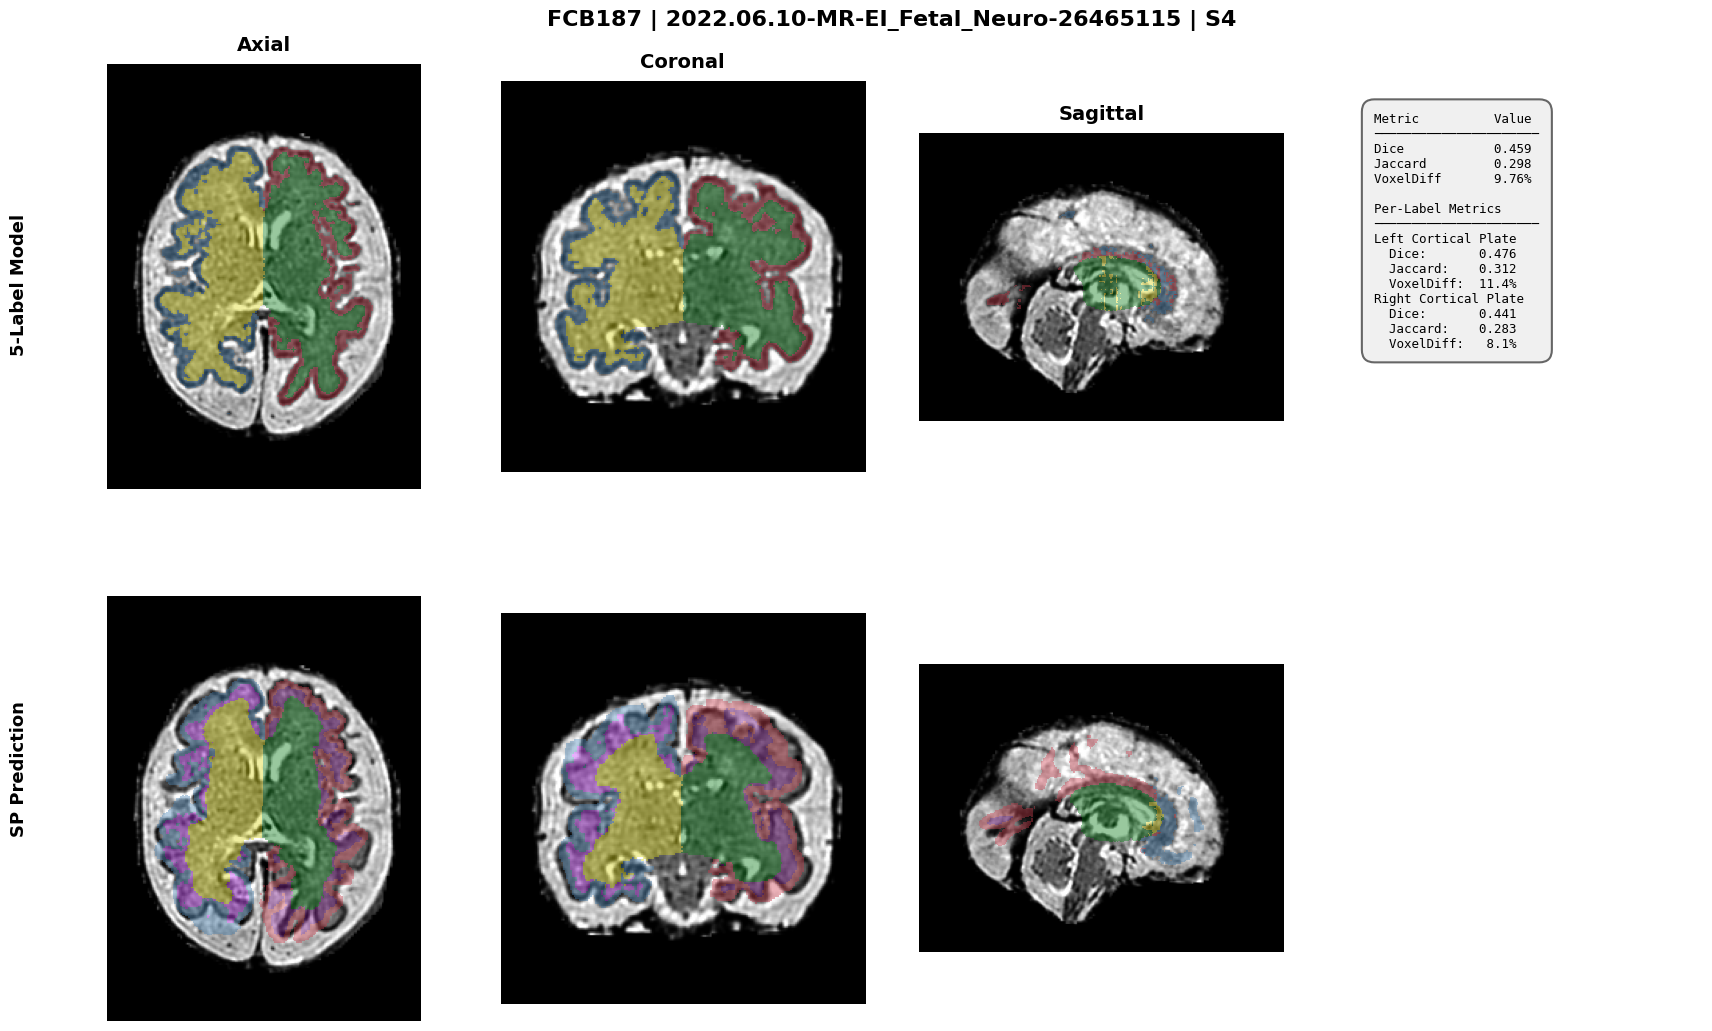

In [5]:
# 3. Process all splits and collect metrics
# FREESURFER_LUT_PATH = "/neuro/users/yair.beltran/Reliability/FreeSurferColorLUT.txt"
FREESURFER_LUT_PATH = "/home/yair/Projects/Reliability/FreeSurferColorLUT.txt"
lut_colors = load_freesurfer_lut(FREESURFER_LUT_PATH)
OPACITY = 0.4

# Store metrics across all splits
all_split_metrics = {}

for split in splits:
    print(f"\n{'='*60}\nProcessing {subject_id} - {split}\n{'='*60}")

    current_path = os.path.join(base_path, subject_id, session_id, split)
    t2_path = os.path.join(current_path, "recon_segmentation/recon_to31_nuc.nii")

    # Find 5label model segmentation file
    seg_model5label_path_option1 = "recon_segmentation/recon_to31_nuc_deep_agg.nii"
    seg_model5label_path_option2 = "recon_segmentation/segmentation_to31_label5.nii"

    global seg_model5label_filename

    if os.path.exists(os.path.join(current_path, seg_model5label_path_option1)):
        seg_model5label_path = os.path.join(current_path, seg_model5label_path_option1)
        seg_model5label_filename = seg_model5label_path_option1
    elif os.path.exists(os.path.join(current_path, seg_model5label_path_option2)):
        seg_model5label_path = os.path.join(current_path, seg_model5label_path_option2)
        seg_model5label_filename = seg_model5label_path_option2
    else:
        raise FileNotFoundError(f"Neither file found:\n  - {seg_model5label_path_option1}\n  - {seg_model5label_path_option2}")
    seg_spmodel_path = os.path.join(current_path, f"anat/segmentations/{subject_id}_{session_id}_nuc_deep_subplate_dilate_mc.nii")

    # Load files
    t2_data = nib.load(t2_path).get_fdata()
    seg1_data = nib.load(seg_model5label_path).get_fdata()
    seg2_data = nib.load(seg_spmodel_path).get_fdata()

    # Filter out CSF label from 5-labels model
    seg1_data[seg1_data == 18] = 0

    # Get slices
    axial_slice = get_middle_slice(t2_data, 2)
    coronal_slice = get_middle_slice(t2_data, 1)
    sagittal_slice = get_middle_slice(t2_data, 0)

    # Extract and normalize
    t2_axial = normalize_intensity(t2_data[:, :, axial_slice])
    t2_coronal = normalize_intensity(t2_data[:, coronal_slice, :])
    t2_sagittal = normalize_intensity(t2_data[sagittal_slice, :, :])

    seg1_axial = seg1_data[:, :, axial_slice]
    seg1_coronal = seg1_data[:, coronal_slice, :]
    seg1_sagittal = seg1_data[sagittal_slice, :, :]
    seg2_axial = seg2_data[:, :, axial_slice]
    seg2_coronal = seg2_data[:, coronal_slice, :]
    seg2_sagittal = seg2_data[sagittal_slice, :, :]

    # Compute metrics ONLY for specified labels
    metrics = {}
    for label in labels_to_measure:
        mask1 = (seg1_data == label).astype(int)
        mask2 = (seg2_data == label).astype(int)
        metrics[int(label)] = {
            'dice': dice_coefficient(mask1, mask2),
            'jaccard': jaccard_score(mask1.flatten(), mask2.flatten(), average='binary'),
            # 'hausdorff': hausdorff_distance(mask1, mask2),  # Commented out for speed during testing
            'voxel_diff': relative_voxel_difference(mask1, mask2),
        }

    overall_mask1 = np.isin(seg1_data, labels_to_measure).astype(int)
    overall_mask2 = np.isin(seg2_data, labels_to_measure).astype(int)
    overall_dice = dice_coefficient(overall_mask1, overall_mask2)
    overall_jaccard = jaccard_score(overall_mask1.flatten(), overall_mask2.flatten(), average='binary')
    overall_voxel_diff = relative_voxel_difference(overall_mask1, overall_mask2)
    # overall_hd = hausdorff_distance(overall_mask1, overall_mask2)  # Commented out for speed during testing

    # Store for cross-split comparison
    all_split_metrics[split] = {
        'per_label': metrics,
        'overall': {'dice': overall_dice, 'voxel_diff': overall_voxel_diff, 'jaccard': overall_jaccard}  # 'hausdorff': overall_hd
    }
    print(f"Overall (labels {labels_to_measure}): Dice={overall_dice:.3f}, Jaccard={overall_jaccard:.3f}, VoxelDiff={overall_voxel_diff:.2f}%")
    # print(f"Overall (labels {labels_to_measure}): Dice={overall_dice:.3f}, Jaccard={overall_jaccard:.3f}, Hausdorff={overall_hd:.2f}mm")
    for label, m in metrics.items():
        print(f"{label_names[label]}: Dice={m['dice']:.3f}, Jaccard={m['jaccard']:.3f}, VoxelDiff={m['voxel_diff']:.2f}%")
        # print(f"{name}: Dice={m['dice']:.3f}, Jaccard={m['jaccard']:.3f}, Hausdorff={m['hausdorff']:.2f}mm")

    # Create colormaps
    max_label1, max_label2 = int(seg1_data.max()), int(seg2_data.max())
    colors1 = np.array([lut_colors.get(i, (1, 1, 1, 1)) for i in range(max_label1 + 1)])
    colors2 = np.array([lut_colors.get(i, (1, 1, 1, 1)) for i in range(max_label2 + 1)])
    seg_cmap1, seg_cmap2 = ListedColormap(colors1), ListedColormap(colors2)

    # Plot
    fig = plt.figure(figsize=(18, 11))
    gs = fig.add_gridspec(2, 4, hspace=0.25, wspace=0.15, left=0.05, right=0.95, top=0.92, bottom=0.05)

    views = [('Axial', t2_axial, seg1_axial, seg2_axial),
             ('Coronal', t2_coronal, seg1_coronal, seg2_coronal),
             ('Sagittal', t2_sagittal, seg1_sagittal, seg2_sagittal)]

    for col, (view_name, t2, s1, s2) in enumerate(views):
        ax = fig.add_subplot(gs[0, col])
        ax.imshow(t2.T, cmap="gray", origin="lower")
        ax.imshow(s1.T, cmap=seg_cmap1, vmin=0, vmax=max_label1, alpha=OPACITY, origin="lower", interpolation="nearest")
        ax.set_title(view_name, fontsize=14, fontweight='bold', pad=10)
        ax.axis('off')

        ax = fig.add_subplot(gs[1, col])
        ax.imshow(t2.T, cmap="gray", origin="lower")
        ax.imshow(s2.T, cmap=seg_cmap2, vmin=0, vmax=max_label2, alpha=OPACITY, origin="lower", interpolation="nearest")
        ax.axis('off')

    fig.text(0.01, 0.72, '5-Label Model', fontsize=13, fontweight='bold', rotation=90, va='center')
    fig.text(0.01, 0.28, 'SP Prediction', fontsize=13, fontweight='bold', rotation=90, va='center')

    # Metrics panel
    ax_metrics = fig.add_subplot(gs[:, 3])
    ax_metrics.axis('off')

    metrics_lines = [
        f"{'Metric':<12} {'Value':>8}",
        "─" * 22,
        f"{'Dice':<12} {overall_dice:>8.3f}",
        f"{'Jaccard':<12} {overall_jaccard:>8.3f}",
        f"{'VoxelDiff':<12} {overall_voxel_diff:>7.2f}%",
        # f"{'Hausdorff':<12} {overall_hd:>7.2f}mm",
        "\n" + "Per-Label Metrics",
        "─" * 22,
    ]
    for label, m in sorted(metrics.items()):
        label_name = label_names.get(int(label), f"Label {int(label)}")
        metrics_lines.extend(
            [
                f"{label_name}",
                f"  Dice:      {m['dice']:>6.3f}",
                f"  Jaccard:   {m['jaccard']:>6.3f}",
                f"  VoxelDiff: {m['voxel_diff']:>5.1f}%",
                # f"  Hausdorff: {m['hausdorff']:>5.1f}mm"
            ]
        )

    metrics_text = '\n'.join(metrics_lines)
    ax_metrics.text(0.1, 0.95, metrics_text, fontsize=9, verticalalignment='top', 
                    family='monospace', bbox=dict(boxstyle='round,pad=1', 
                    facecolor='#f0f0f0', edgecolor='#666666', linewidth=1.5))

    fig.suptitle(f'{subject_id} | {session_id} | {split}', fontsize=16, fontweight='bold', y=0.97)

    plt.show()


Processing S1 (SP Model)...



Processing S2 (SP Model)...



Processing S3 (SP Model)...



Processing S4 (SP Model)...



Processing S1 (5-Label Model)...



Processing S2 (5-Label Model)...



Processing S3 (5-Label Model)...



Processing S4 (5-Label Model)...


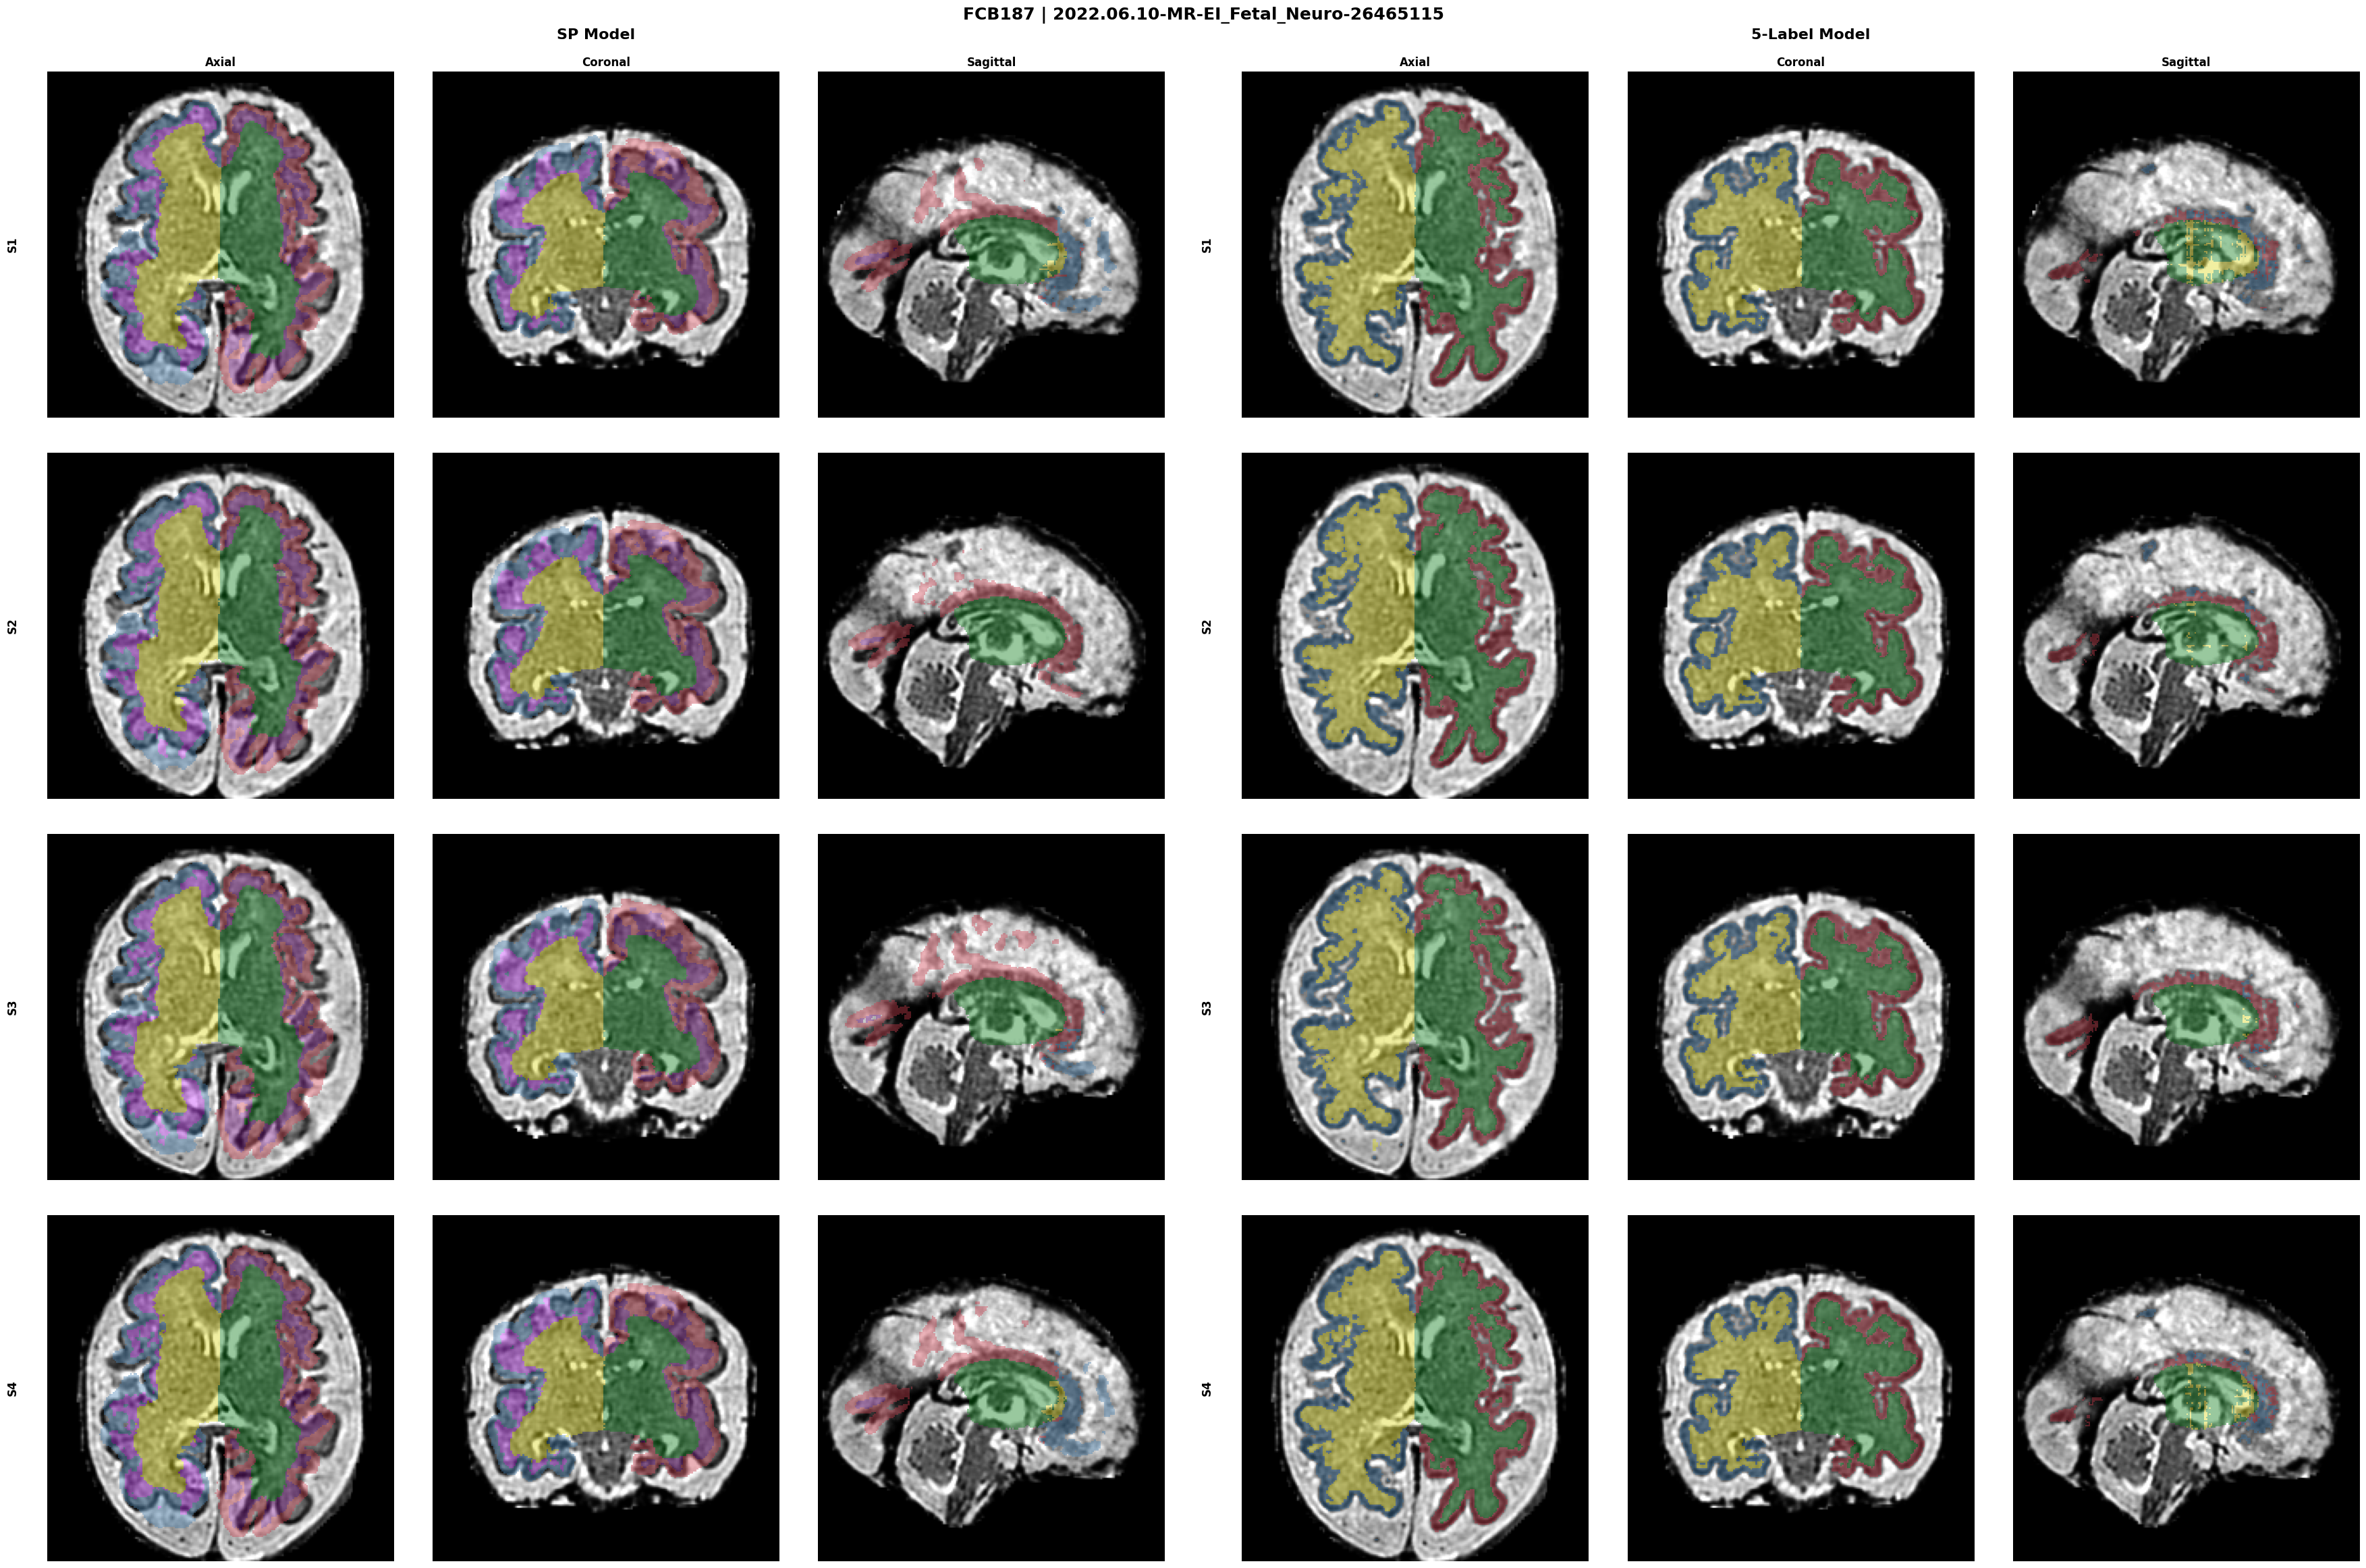

In [6]:
# 3b split-comparision visualization of each model.

# Function to crop image to square (centered crop)
def crop_to_square(img, seg):
    """Crop image and segmentation to square by removing excess from the larger dimension"""
    h, w = img.shape
    
    if h == w:
        return img, seg
    
    if h > w:
        # Height is larger, crop vertically (centered)
        excess = h - w
        start = excess // 2
        end = start + w
        return img[start:end, :], seg[start:end, :]
    else:
        # Width is larger, crop horizontally (centered)
        excess = w - h
        start = excess // 2
        end = start + h
        return img[:, start:end], seg[:, start:end]

# Function to plot model comparison across splits
def plot_model_splits(axes_grid, seg_path_func, model_name, filter_csf=False):
    """
    Plot 4 splits x 3 views for a given model.
    
    Parameters:
    -----------
    axes_grid : array of axes
        4x3 grid of matplotlib axes to plot into
    seg_path_func : function
        Function that takes (current_path) and returns segmentation file path
    model_name : str
        Name of the model for logging
    filter_csf : bool
        Whether to filter out CSF label (18)
    """
    for row_idx, split in enumerate(splits):
        print(f"\nProcessing {split} ({model_name})...")
        
        # Load data for this split
        current_path = os.path.join(base_path, subject_id, session_id, split)
        t2_path = os.path.join(current_path, "recon_segmentation/recon_to31_nuc.nii")
        seg_path = seg_path_func(current_path)
        
        t2_data = nib.load(t2_path).get_fdata()
        seg_data = nib.load(seg_path).get_fdata()
        
        # Filter out CSF label if requested
        if filter_csf:
            seg_data[seg_data == 18] = 0
        
        # Get middle slices
        axial_slice = get_middle_slice(t2_data, 2)
        coronal_slice = get_middle_slice(t2_data, 1)
        sagittal_slice = get_middle_slice(t2_data, 0)
        
        # Extract slices
        t2_axial = normalize_intensity(t2_data[:, :, axial_slice])
        t2_coronal = normalize_intensity(t2_data[:, coronal_slice, :])
        t2_sagittal = normalize_intensity(t2_data[sagittal_slice, :, :])
        
        seg_axial = seg_data[:, :, axial_slice]
        seg_coronal = seg_data[:, coronal_slice, :]
        seg_sagittal = seg_data[sagittal_slice, :, :]
        
        # Create colormap
        max_label = int(seg_data.max())
        colors = np.array([lut_colors.get(i, (1, 1, 1, 1)) for i in range(max_label + 1)])
        seg_cmap = ListedColormap(colors)
        
        # Apply cropping to make each slice square
        t2_axial_crop, seg_axial_crop = crop_to_square(t2_axial.T, seg_axial.T)
        t2_coronal_crop, seg_coronal_crop = crop_to_square(t2_coronal.T, seg_coronal.T)
        t2_sagittal_crop, seg_sagittal_crop = crop_to_square(t2_sagittal.T, seg_sagittal.T)
        
        # Plot axial
        axes_grid[row_idx, 0].imshow(t2_axial_crop, cmap="gray", origin="lower")
        axes_grid[row_idx, 0].imshow(seg_axial_crop, cmap=seg_cmap, vmin=0, vmax=max_label, alpha=OPACITY, origin="lower", interpolation="nearest")
        if row_idx == 0:
            axes_grid[row_idx, 0].set_title('Axial', fontsize=12, fontweight='bold')
        axes_grid[row_idx, 0].text(-0.1, 0.5, split, fontsize=12, fontweight='bold', 
                              transform=axes_grid[row_idx, 0].transAxes, rotation=90, 
                              ha='center', va='center')
        axes_grid[row_idx, 0].axis('off')
        
        # Plot coronal
        axes_grid[row_idx, 1].imshow(t2_coronal_crop, cmap="gray", origin="lower")
        axes_grid[row_idx, 1].imshow(seg_coronal_crop, cmap=seg_cmap, vmin=0, vmax=max_label, alpha=OPACITY, origin="lower", interpolation="nearest")
        if row_idx == 0:
            axes_grid[row_idx, 1].set_title('Coronal', fontsize=12, fontweight='bold')
        axes_grid[row_idx, 1].axis('off')
        
        # Plot sagittal
        axes_grid[row_idx, 2].imshow(t2_sagittal_crop, cmap="gray", origin="lower")
        axes_grid[row_idx, 2].imshow(seg_sagittal_crop, cmap=seg_cmap, vmin=0, vmax=max_label, alpha=OPACITY, origin="lower", interpolation="nearest")
        if row_idx == 0:
            axes_grid[row_idx, 2].set_title('Sagittal', fontsize=12, fontweight='bold')
        axes_grid[row_idx, 2].axis('off')

# Create a single figure with 1x2 layout (two columns)
fig = plt.figure(figsize=(36, 24))
gs = fig.add_gridspec(1, 2, wspace=0.05, left=0.02, right=0.98, top=0.94, bottom=0.02)

# Create 4x3 grid for SP Model (left side)
gs_left = gs[0, 0].subgridspec(4, 3, hspace=0.1, wspace=0.05)
axes_sp = np.array([[fig.add_subplot(gs_left[i, j]) for j in range(3)] for i in range(4)])

# Create 4x3 grid for 5-Label Model (right side)
gs_right = gs[0, 1].subgridspec(4, 3, hspace=0.1, wspace=0.05)
axes_5label = np.array([[fig.add_subplot(gs_right[i, j]) for j in range(3)] for i in range(4)])

# Plot SP Model
sp_path_func = lambda current_path: os.path.join(current_path, f"anat/segmentations/{subject_id}_{session_id}_nuc_deep_subplate_dilate_mc.nii")
plot_model_splits(axes_sp, sp_path_func, "SP Model", filter_csf=False)

# Plot 5-Label Model
five_label_path_func = lambda current_path: os.path.join(current_path, seg_model5label_filename)
plot_model_splits(axes_5label, five_label_path_func, "5-Label Model", filter_csf=True)

# Add overall title and model labels
fig.suptitle(f'{subject_id} | {session_id}', fontsize=18, fontweight='bold', y=0.98)
fig.text(0.25, 0.96, 'SP Model', fontsize=16, fontweight='bold', ha='center')
fig.text(0.75, 0.96, '5-Label Model', fontsize=16, fontweight='bold', ha='center')

# Store the figure for later use instead of showing immediately
split_comparison_fig = fig

with PdfPages(pdf_output_path) as pdf:
    pdf.savefig(split_comparison_fig, bbox_inches="tight")
    pdf.close()

In [7]:
# 4. Cross-split comparison function
def cross_split_reliability_analysis(
    segmentation_files, labels_to_compare, title, label_description="", 
    csv_path="cross_split_metrics.csv", subject_id=None, session_id=None, model_name=None
):
    """
    Perform cross-split reliability analysis by comparing segmentations across splits.

    Parameters:
    -----------
    segmentation_files : dict
        Dictionary mapping split names to file paths of segmentations to compare
    labels_to_compare : list
        List of label indices to include in the comparison
    title : str
        Title for the plot
    label_description : str
        Description of what labels are being compared (for print output)
    csv_path : str
        Path to CSV file where metrics will be saved (default: "cross_split_metrics.csv")
    subject_id : str
        Subject identifier for CSV records
    session_id : str
        Session identifier for CSV records
    model_name : str
        Model name for CSV records (e.g., "SP Model", "5-Label Model")
    
    Returns:
    --------
    fig : matplotlib.figure.Figure
        The generated matplotlib figure with comparison matrices
    metric_matrices : dict
        Dictionary of metric matrices for each metric type
    """
    print(f"\n{'='*60}\n{title}\n{'='*60}")

    # Load existing CSV data if available
    existing_metrics = {}
    if os.path.exists(csv_path):
        df_existing = pd.read_csv(csv_path)
        
        # Filter for current subject/session/model/labels
        # Convert both to string for comparison, handling potential type mismatches
        mask = (
            (df_existing['subject_id'].astype(str) == str(subject_id)) &
            (df_existing['session_id'].astype(str) == str(session_id)) &
            (df_existing['model'].astype(str) == str(model_name)) &
            (df_existing['labels'].astype(str) == str(labels_to_compare))
        )
        df_filtered = df_existing[mask]

        # Create lookup dictionary for existing metrics
        for _, row in df_filtered.iterrows():
            key = (row['split1'], row['split2'])
            existing_metrics[key] = {
                'dice': row['dice'],
                'jaccard': row['jaccard'],
                'relative_diff': row['relative_diff']
            }
            # Also add reverse key for symmetry (same metrics apply in both directions)
            key_reverse = (row['split2'], row['split1'])
            existing_metrics[key_reverse] = {
                'dice': row['dice'],
                'jaccard': row['jaccard'],
                'relative_diff': row['relative_diff']
            }

        if len(existing_metrics) > 0:
            print(f"Found {len(df_filtered)} existing metric(s) in CSV, will reuse them")
    # Load segmentations for all splits (only if needed)
    segmentations = {}
    split_names = list(segmentation_files.keys())
    n_splits = len(split_names)

    # Compute pairwise metrics between all splits
    # metrics_names = ["dice", "jaccard", "hausdorff"]
    metrics_names = ["dice", "jaccard", "relative_diff"]

    # Create matrices for each metric
    metric_matrices = {
        metric: np.zeros((n_splits, n_splits)) for metric in metrics_names
    }

    print(f"\nProcessing pairwise metrics between splits...")
    if label_description:
        print(f"Measuring labels: {label_description}")
    print()  # Add blank line for readability

    # Define the unique comparison pairs (upper triangle including diagonal)
    comparisons = []
    for i in range(n_splits):
        for j in range(i, n_splits):
            comparisons.append((i, j))

    # Track metrics that need to be computed vs reused
    computed_count = 0
    reused_count = 0

    # Process each comparison exactly once
    for idx, (i, j) in enumerate(comparisons, 1):
        split1 = split_names[i]
        split2 = split_names[j]

        # Check if metrics exist in CSV
        key = (split1, split2)
        if key in existing_metrics:
            # Reuse existing metrics
            dice = existing_metrics[key]['dice']
            jaccard = existing_metrics[key]['jaccard']
            relative_diff = existing_metrics[key]['relative_diff']
            reused_count += 1
            status = "[CACHED]"
        else:
            # Need to compute - load segmentations if not already loaded
            if split1 not in segmentations:
                segmentations[split1] = nib.load(segmentation_files[split1]).get_fdata()
                print(f"Loaded segmentation for {split1}")
            if split2 not in segmentations:
                segmentations[split2] = nib.load(segmentation_files[split2]).get_fdata()
                print(f"Loaded segmentation for {split2}")

            seg1 = segmentations[split1]
            seg2 = segmentations[split2]

            # Create masks for labels of interest
            mask1 = np.isin(seg1, labels_to_compare).astype(int)
            mask2 = np.isin(seg2, labels_to_compare).astype(int)

            # Compute metrics
            dice = dice_coefficient(mask1, mask2)
            jaccard = jaccard_score(mask1.flatten(), mask2.flatten(), average="binary")
            # hausdorff = hausdorff_distance(mask1, mask2)
            relative_diff = relative_voxel_difference(mask1, mask2)
            computed_count += 1
            status = "[COMPUTED]"

        # Store in matrix (both positions for symmetry)
        metric_matrices["dice"][i, j] = dice
        metric_matrices["jaccard"][i, j] = jaccard
        # metric_matrices["hausdorff"][i, j] = hausdorff
        metric_matrices["relative_diff"][i, j] = relative_diff

        # Mirror to lower triangle if not on diagonal
        if i != j:
            metric_matrices["dice"][j, i] = dice
            metric_matrices["jaccard"][j, i] = jaccard
            # metric_matrices["hausdorff"][j, i] = hausdorff
            metric_matrices["relative_diff"][j, i] = relative_diff

        # Print immediately after computation with progress counter
        print(
            # f"[{idx}/{len(comparisons)}] {split1} vs {split2}: Dice={dice:.3f}, Jaccard={jaccard:.3f}, Hausdorff={hausdorff:.2f}mm"
            f"{status} [{idx}/{len(comparisons)}] {split1} vs {split2}: Dice={dice:.3f}, Jaccard={jaccard:.3f}, Relative Voxel Diff={relative_diff:.3f}%"
        )

        # Force flush to ensure immediate output in Jupyter
        import sys

        sys.stdout.flush()

    print(f"\nMetrics: {computed_count} computed, {reused_count} reused from CSV")

    # Save metrics to CSV file
    csv_records = []
    for idx, (i, j) in enumerate(comparisons, 1):
        # Skip diagonal (same split comparisons)
        if i != j:
            split1 = split_names[i]
            split2 = split_names[j]

            # Only save if this was a newly computed metric (not reused from CSV)
            key = (split1, split2)
            if key not in existing_metrics:
                record = {
                    'subject_id': subject_id,
                    'session_id': session_id,
                    'model': model_name,
                    'labels': str(labels_to_compare),
                    'split1': split1,
                    'split2': split2,
                    'dice': metric_matrices["dice"][i, j],
                    'jaccard': metric_matrices["jaccard"][i, j],
                    'relative_diff': metric_matrices["relative_diff"][i, j]
                }
                csv_records.append(record)

    # Only update CSV if there are new records to add
    if len(csv_records) > 0:
        df_new = pd.DataFrame(csv_records)

        # Append to existing CSV or create new one
        if os.path.exists(csv_path):
            df_existing = pd.read_csv(csv_path)
            df_combined = pd.concat([df_existing, df_new], ignore_index=True)
            df_combined.to_csv(csv_path, index=False)
            print(f"\nAppended {len(csv_records)} new records to {csv_path}")
        else:
            df_new.to_csv(csv_path, index=False)
            print(f"\nCreated {csv_path} with {len(csv_records)} records")
    else:
        print(f"\nNo new records to add to {csv_path} (all metrics were reused)")

    # Plot the three matrices
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    fig.suptitle(title, fontsize=16, fontweight="bold")

    for metric_idx, metric in enumerate(metrics_names):
        ax = axes[metric_idx]
        matrix = metric_matrices[metric]

        # Use appropriate colormap (green=good for dice/jaccard, reversed for hausdorff and relative_diff)
        # For relative_diff, set a more reasonable vmax to avoid drastic color changes
        if metric == "relative_diff":
            vmax_value = max(10, matrix.max())  # Use at least 10% for scaling
        elif metric == "hausdorff":
            vmax_value = matrix.max()
        else:
            vmax_value = 1

        im = ax.imshow(
            matrix,
            cmap="RdYlGn" if metric not in ["hausdorff", "relative_diff"] else "RdYlGn_r",
            aspect="auto",
            vmin=0,
            vmax=vmax_value,
        )

        ax.set_xticks(range(n_splits))
        ax.set_yticks(range(n_splits))
        ax.set_xticklabels(split_names)
        ax.set_yticklabels(split_names)
        ax.set_xlabel("Split", fontsize=12)
        ax.set_ylabel("Split", fontsize=12)
        if metric == "relative_diff":
            ax.set_title(f"Relative voxel difference", fontweight="bold", fontsize=14)
        else:
            ax.set_title(f"{metric.capitalize()}", fontweight="bold", fontsize=14) 

        # Annotate cells with values
        for i in range(n_splits):
            for j in range(n_splits):
                value = matrix[i, j]
                # Use white text for dark cells, black for light cells
                text_color = (
                    "white"
                    if (metric not in ["hausdorff", "relative_diff"] and value < 0.5)
                    else "black"
                )
                # Format with percentage sign for relative_diff
                if metric == "relative_diff":
                    text = f"{value:.2f}%"
                else:
                    text = f"{value:.3f}"

                ax.text(
                    j,
                    i,
                    text,
                    ha="center",
                    va="center",
                    color=text_color,
                    fontsize=11,
                    fontweight="bold",
                )

        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

    plt.tight_layout()

    # Print summary statistics
    print("\n" + "=" * 60)
    print(f"Summary Statistics - {title}")
    print("=" * 60)

    for metric in metrics_names:
        matrix = metric_matrices[metric]

        # Get off-diagonal values (actual cross-split comparisons)
        off_diagonal = matrix[~np.eye(n_splits, dtype=bool)]
        diagonal = np.diag(matrix)
        print(f"\n{metric.capitalize()}:")
        print(
            f"  Diagonal (same split):     Mean={np.mean(diagonal):.3f}, Std={np.std(diagonal):.3f}"
        )
        print(
            f"  Off-diagonal (different):  Mean={np.mean(off_diagonal):.3f}, Std={np.std(off_diagonal):.3f}"
        )
        print(
            f"  Overall matrix:            Min={matrix.min():.3f}, Max={matrix.max():.3f}"
        )

        # Reliability indicator: lower std in off-diagonal means more reliable
        print(f"  Reliability (lower std = better): {np.std(off_diagonal):.4f}")

    return fig, metric_matrices


Generating reliability analysis report for FCB187

Cross-Split Reliability: Cortical Plate (SP Model) - FCB187

Processing pairwise metrics between splits...
Measuring labels: Cortical Plate (Labels 1, 42)



Loaded segmentation for S1


[COMPUTED] [1/10] S1 vs S1: Dice=1.000, Jaccard=1.000, Relative Voxel Diff=0.000%


Loaded segmentation for S2


[COMPUTED] [2/10] S1 vs S2: Dice=0.789, Jaccard=0.651, Relative Voxel Diff=2.035%


...

[COMPUTED] [10/10] S4 vs S4: Dice=1.000, Jaccard=1.000, Relative Voxel Diff=0.000%



Metrics: 10 computed, 0 reused from CSV

Appended 6 new records to cross_split_metrics.csv



Summary Statistics - Cross-Split Reliability: Cortical Plate (5-Label Model) - FCB187

Dice:
  Diagonal (same split):     Mean=1.000, Std=0.000
  Off-diagonal (different):  Mean=0.820, Std=0.031
  Overall matrix:            Min=0.795, Max=1.000
  Reliability (lower std = better): 0.0305

Jaccard:
  Diagonal (same split):     Mean=1.000, Std=0.000
  Off-diagonal (different):  Mean=0.696, Std=0.045
  Overall matrix:            Min=0.660, Max=1.000
  Reliability (lower std = better): 0.0455

Relative_diff:
  Diagonal (same split):     Mean=0.000, Std=0.000
  Off-diagonal (different):  Mean=1.839, Std=0.839
  Overall matrix:            Min=0.000, Max=3.345
  Reliability (lower std = better): 0.8386



Appending split comparison plot to reports/FCB187_2022.06.10-MR-EI_Fetal_Neuro-26465115_reliability_report.pdf


Appending combined reliability analysis to reports/FCB187_2022.06.10-MR-EI_Fetal_Neuro-26465115_reliability_report.pdf


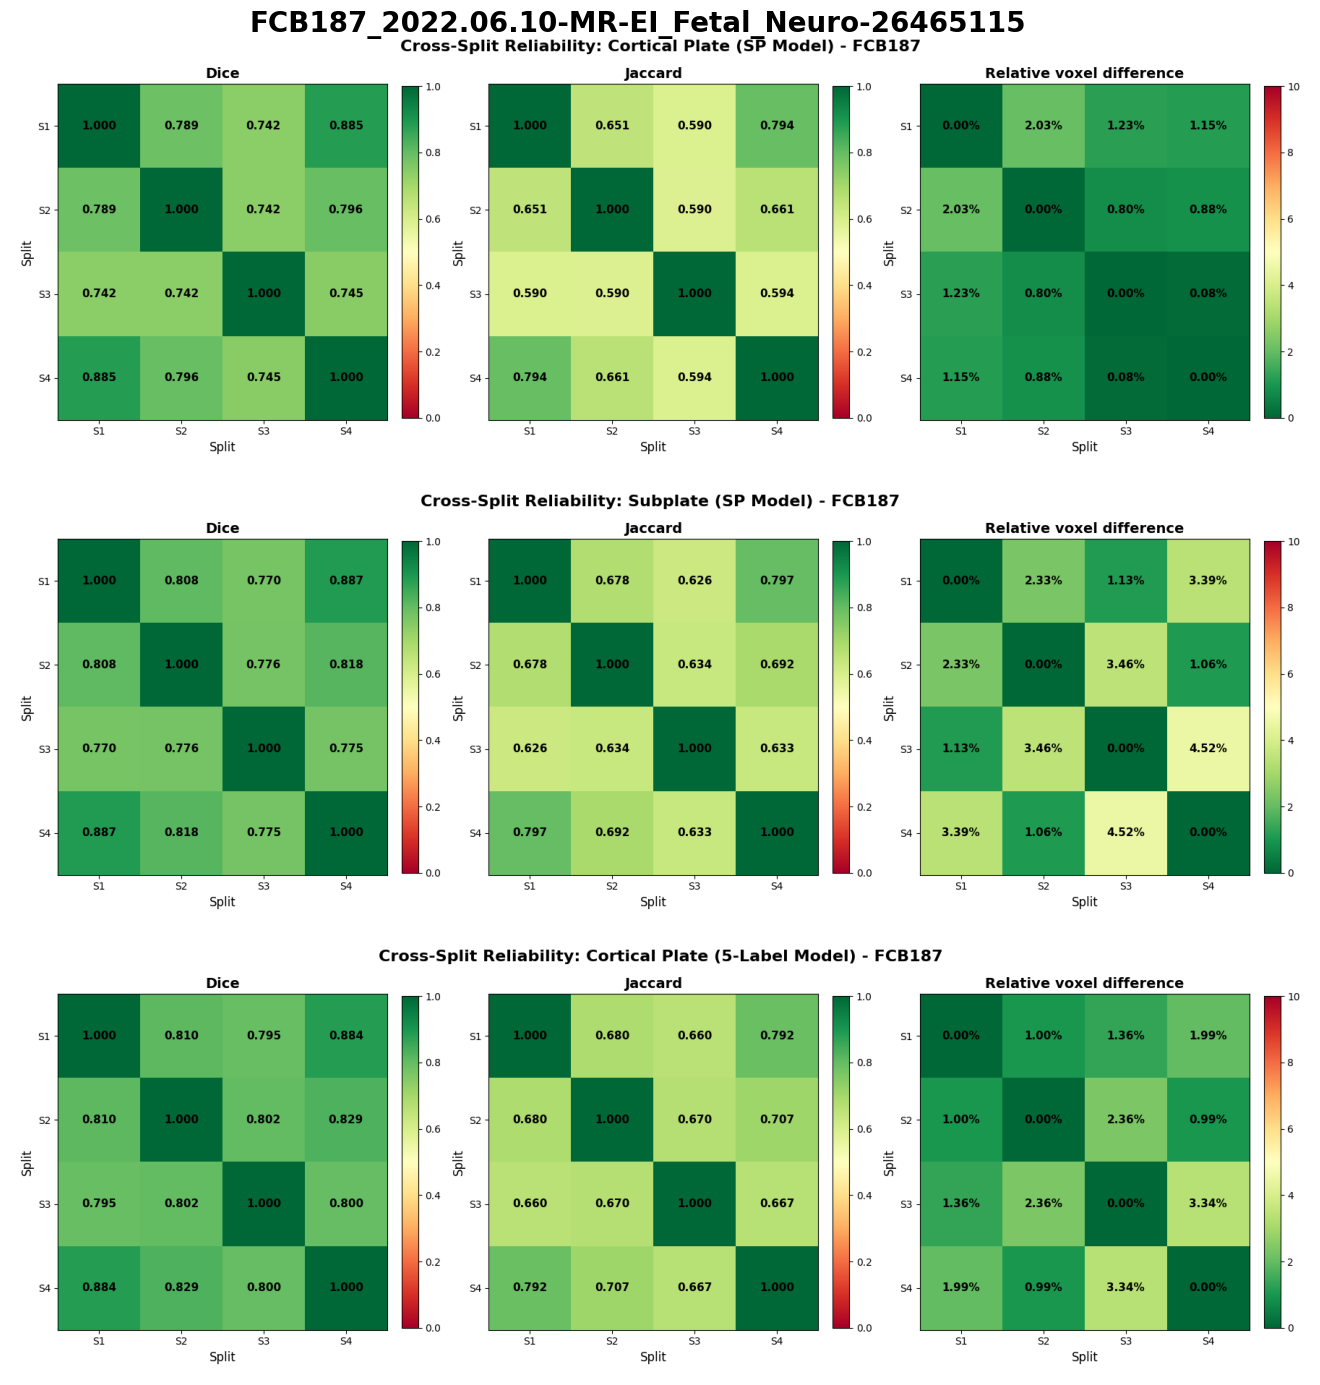


PDF report saved to: reports/FCB187_2022.06.10-MR-EI_Fetal_Neuro-26465115_reliability_report.pdf



In [8]:
# 5. Combined Reliability Analysis - Saves to PDF
# This cell runs all three reliability analyses and saves them to a multi-page PDF

# Build file paths for both models
sp_model_files = {}
five_label_model_files = {}

for split in splits:
    current_path = os.path.join(base_path, subject_id, session_id, split)
    sp_model_files[split] = os.path.join(current_path, f"anat/segmentations/{subject_id}_{session_id}_nuc_deep_subplate_dilate_mc.nii")
    five_label_model_files[split] = os.path.join(current_path, seg_model5label_filename)

# Define label groups
cp_labels = [1, 42]  # Cortical Plate
sp_labels = [4, 5]    # Subplate

print(f"\n{'='*80}\nGenerating reliability analysis report for {subject_id}\n{'='*80}")

# Run all three analyses and collect figures
fig1, metrics1 = cross_split_reliability_analysis(
    segmentation_files=sp_model_files,
    labels_to_compare=cp_labels,
    title=f'Cross-Split Reliability: Cortical Plate (SP Model) - {subject_id}',
    label_description="Cortical Plate (Labels 1, 42)",
    csv_path="cross_split_metrics.csv",
    subject_id=subject_id,
    session_id=session_id,
    model_name="SP Model - Cortical Plate"
)

fig2, metrics2 = cross_split_reliability_analysis(
    segmentation_files=sp_model_files,
    labels_to_compare=sp_labels,
    title=f'Cross-Split Reliability: Subplate (SP Model) - {subject_id}',
    label_description="Subplate (Labels 4, 5)",
    csv_path="cross_split_metrics.csv",
    subject_id=subject_id,
    session_id=session_id,
    model_name="SP Model - Subplate"
)

fig3, metrics3 = cross_split_reliability_analysis(
    segmentation_files=five_label_model_files,
    labels_to_compare=cp_labels,
    title=f'Cross-Split Reliability: Cortical Plate (5-Label Model) - {subject_id}',
    label_description="Cortical Plate (Labels 1, 42)",
    csv_path="cross_split_metrics.csv",
    subject_id=subject_id,
    session_id=session_id,
    model_name="5-Label Model - Cortical Plate"
)

# Combine the three figures vertically into one figure
combined_fig = plt.figure(figsize=(18, 14))
combined_fig.suptitle(f'{subject_id}_{session_id}', fontsize=20, fontweight='bold', y=0.995)

# Create gridspec for 3 rows with minimal spacing
gs = combined_fig.add_gridspec(3, 1, hspace=0.05, top=0.98, bottom=0.02)

# Copy each figure into the combined figure
for idx, fig in enumerate([fig1, fig2, fig3]):
    # Create subplot for this row
    ax_combined = combined_fig.add_subplot(gs[idx, 0])
    ax_combined.axis('off')
    
    # Render the original figure to an image and display it
    fig.canvas.draw()
    img = np.frombuffer(fig.canvas.buffer_rgba(), dtype=np.uint8)
    img = img.reshape(fig.canvas.get_width_height()[::-1] + (4,))
    ax_combined.imshow(img)
    
    # Close the original figure to free memory
    plt.close(fig)

# Save to PDF
mode = 'a' if os.path.exists(pdf_output_path) else 'w'
action = "Appending" if mode == 'a' else "Creating"

with PdfPages(pdf_output_path) as pdf:
    # Save the split comparison figure (from cell 3b) if it exists
    if 'split_comparison_fig' in globals():
        pdf.savefig(split_comparison_fig, bbox_inches='tight')
        print(f"\n{action} split comparison plot to {pdf_output_path}")
        plt.close(split_comparison_fig)
    
    # Save the combined reliability analysis figure
    pdf.savefig(combined_fig, bbox_inches='tight')
    print(f"Appending combined reliability analysis to {pdf_output_path}")

# Display the combined figure
plt.figure(combined_fig.number)
plt.show()
    
plt.close(combined_fig)

print(f"\n{'='*80}")
print(f"PDF report saved to: {pdf_output_path}")
print(f"{'='*80}\n")